In [ ]:
# Import packages
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from scipy.stats import norm
from pathlib import Path

# Pathways 
out_dir = Path("..") / "plots" / "eda"
out_dir.mkdir(parents=True, exist_ok=True)
out_path_2d = out_dir / "black2d.pdf"
out_path_3d = out_dir / "black3d.pdf"

### Global parameters

In [ ]:
# Answer to the universe and everything
np.random.seed(42)

# Input values
strike = 100.0  
maturity = 2.0
rf = 0.05
volatility = 0.20

### Defining the analytical Black-Scholes model

In [ ]:
def bs(S, K, T, r, sigma, type="call"):
    
    # Preventing division ny zero if T is 0
    T = np.maximum(T, 2e-20)

    # Calculating d2 and d2 
    d1 = (np.log(S/K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)

    # Calculating prices depending on call or put,
    # while raising error if user selects neither
    if type == "call":
        price = S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)
    elif type == "put":
        price = K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)
    else:
        raise ValueError("do either call or put option type")
    
    # Returning the analytically sound price of the option
    return price


### Calculating prices

In [ ]:
# Generating an array of underlying asset prices
S_values = np.linspace(50, 150, 100)

# Calculating call and put prices
call = bs(S=S_values, K=strike, T=maturity, r=rf, sigma=volatility, type="call")
put = bs(S=S_values, K=strike, T=maturity, r=rf, sigma=volatility, type="put")

### Plotting

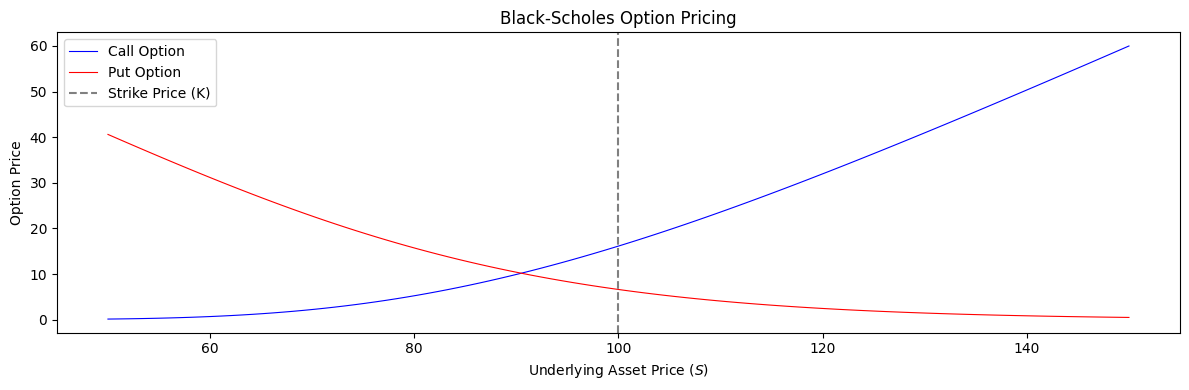

In [ ]:
# Setting up the figure plotting
plt.figure(figsize=(12,4))

# Plotting the call and put options
plt.plot(S_values, call, label="Call Option", color="blue", lw=0.8)
plt.plot(S_values, put, label="Put Option", color="red", lw=0.8)

# Inserting the strike price
plt.axvline(x=strike, color="gray", linestyle="--", label="Strike Price (K)")

# Adding title, axes titles, and legend
plt.title("Black-Scholes Option Pricing")
plt.xlabel("Underlying Asset Price ($S$)")
plt.ylabel("Option Price")
plt.legend()

# Tight layout
plt.tight_layout()

# # Saving and showing the figure
plt.savefig(out_path_2d, bbox_inches="tight")
plt.show()

### Calculating more prices

In [ ]:
# Defining underlying prices (S) and
# time to maturity (T)
S_values = np.linspace(50, 150, 50)
T_values = np.linspace(0.01, 2.0, 50)

# Making a 2D coordinate grid
S_grid, T_grid = np.meshgrid(S_values, T_values)

# Pass grid directly into function
call_surface = bs(S_grid, strike, T_grid, rf, volatility, type="call")
put_surface = bs(S_grid, strike, T_grid, rf, volatility, type="put")

### Plotting now in 3D

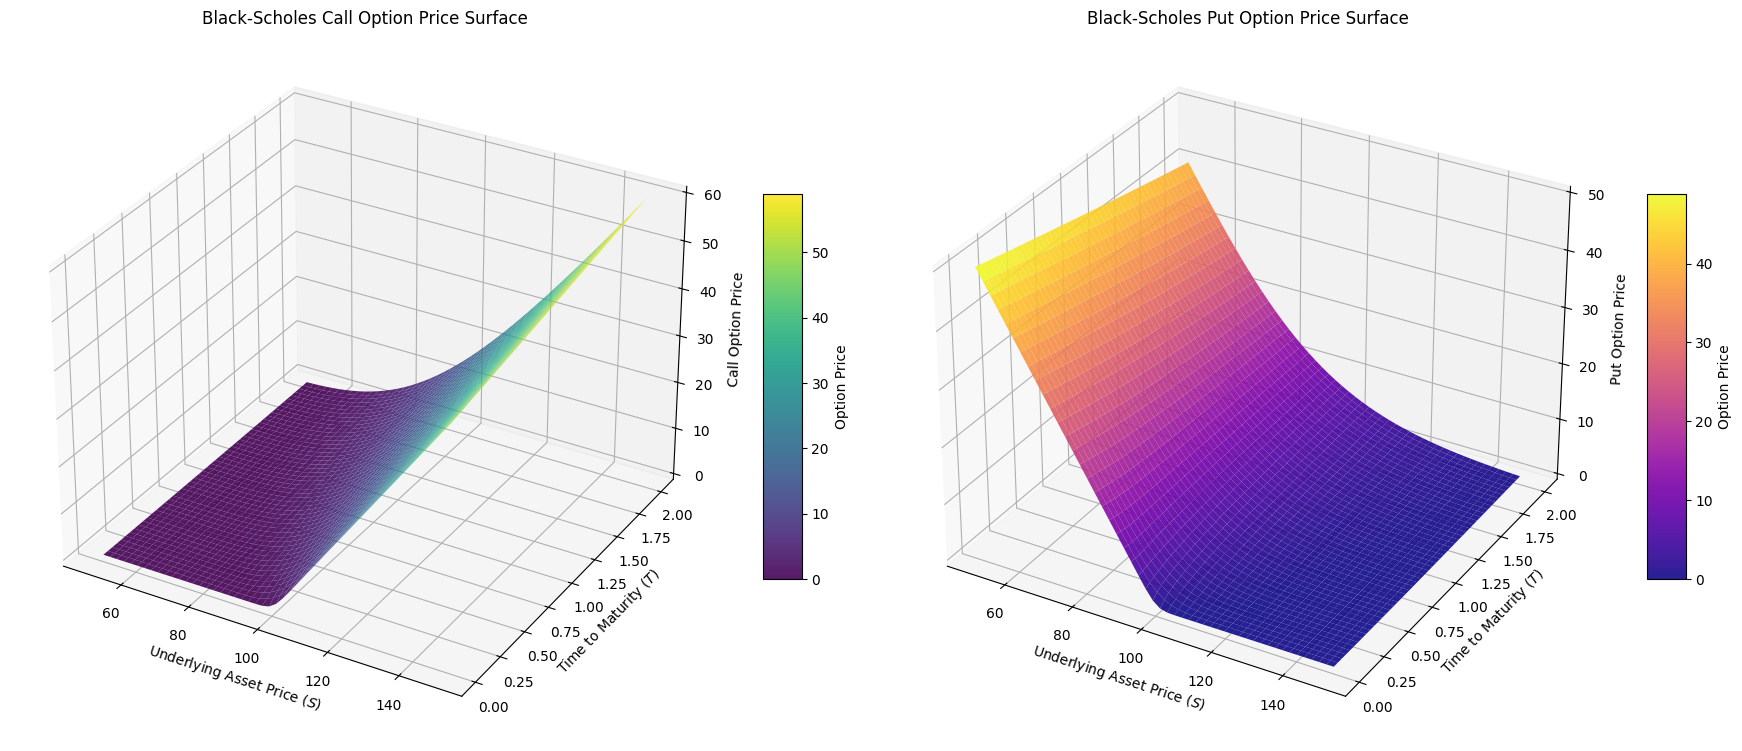

In [ ]:
# Setting up a figure with 1 row and 2 columns
fig = plt.figure(figsize=(18,8))

# Left plot
ax1 = fig.add_subplot(121, projection="3d")

# Adding surface
surf1 = ax1.plot_surface(S_grid, T_grid, call_surface, cmap=cm.viridis, edgecolor="none", alpha=0.9)

# Title and axes labels
ax1.set_title("Black-Scholes Call Option Price Surface")
ax1.set_xlabel("Underlying Asset Price ($S$)")
ax1.set_ylabel("Time to Maturity ($T$)")
ax1.set_zlabel("Call Option Price")

# Adding the continouos colourbar
fig.colorbar(surf1, ax=ax1, shrink=0.5, aspect=10, label="Option Price")

# Right plot
ax2 = fig.add_subplot(122, projection="3d")

# Adding surface
surf2 = ax2.plot_surface(S_grid, T_grid, put_surface, cmap=cm.plasma, edgecolor="none", alpha=0.9) 

# Title and axes labels
ax2.set_title("Black-Scholes Put Option Price Surface")
ax2.set_xlabel("Underlying Asset Price ($S$)")
ax2.set_ylabel("Time to Maturity ($T$)")
ax2.set_zlabel("Put Option Price") 

# Adding the continouos colourbar
fig.colorbar(surf2, ax=ax2, shrink=0.5, aspect=10, label="Option Price")

# Tight layout
plt.tight_layout()

# # Saving and showing the figure
plt.savefig(out_path_3d, bbox_inches="tight")
plt.show()